### Libraries

In [2]:
import numpy as np
import pandas as pd
import os
import yaml

### Step 1:	Load preprocessed splits

In [3]:
config_file = os.path.join("..","config","config.yaml")

with open(config_file,"r") as f:
    config = yaml.safe_load(f)
    
root_path = os.path.dirname(os.path.dirname(os.path.abspath(config_file)))
processed_path = os.path.join(root_path,config["paths"]["processed_data"])

print("The Processed Data has be saved to: ",processed_path)

The Processed Data has be saved to:  c:\Users\DELL\Desktop\loan-risk-system\data/processed_data/


In [4]:
X_train_cls_processed = pd.read_csv(os.path.join(processed_path,"X_train_cls_processed.csv"))
X_test_cls_processed = pd.read_csv(os.path.join(processed_path,"X_test_cls_processed.csv"))
X_val_cls_processed = pd.read_csv(os.path.join(processed_path,"X_val_cls_processed.csv"))
y_train_cls_processed = pd.read_csv(os.path.join(processed_path,"y_train_cls_processed.csv"))
y_test_cls_processed = pd.read_csv(os.path.join(processed_path,"y_test_cls_processed.csv"))
y_val_cls_processed = pd.read_csv(os.path.join(processed_path,"y_val_cls_processed.csv"))

print("X_train_cls_processed shape is: ",X_train_cls_processed.shape)
print("X_test_cls_processed shape is: ",X_test_cls_processed.shape)
print("X_val_cls_processed shape is: ",X_val_cls_processed.shape)
print("y_train_cls_processed shape is: ",y_train_cls_processed.shape)
print("y_test_cls_processed shape is: ",y_test_cls_processed.shape)
print("y_val_cls_processed shape is: ",y_val_cls_processed.shape)

print("All Classification Processed Dataset Fully Loaded...")

X_train_cls_processed shape is:  (27577, 17)
X_test_cls_processed shape is:  (2444, 17)
X_val_cls_processed shape is:  (2444, 17)
y_train_cls_processed shape is:  (27577, 1)
y_test_cls_processed shape is:  (2444, 1)
y_val_cls_processed shape is:  (2444, 1)
All Classification Processed Dataset Fully Loaded...


In [5]:
X_train_reg_processed = pd.read_csv(os.path.join(processed_path,"X_train_reg_processed.csv"))
X_test_reg_processed = pd.read_csv(os.path.join(processed_path,"X_test_reg_processed.csv"))
X_val_reg_processed = pd.read_csv(os.path.join(processed_path,"X_val_reg_processed.csv"))
y_train_reg_processed = pd.read_csv(os.path.join(processed_path,"y_train_reg_processed.csv"))
y_test_reg_processed = pd.read_csv(os.path.join(processed_path,"y_test_reg_processed.csv"))
y_val_reg_processed = pd.read_csv(os.path.join(processed_path,"y_val_reg_processed.csv"))

print("X_train_reg_processed shape is: ",X_train_reg_processed.shape)
print("X_test_reg_processed shape is: ",X_test_reg_processed.shape)
print("X_val_reg_processed shape is: ",X_val_reg_processed.shape)
print("y_train_reg_processed shape is: ",y_train_reg_processed.shape)
print("y_test_reg_processed shape is: ",y_test_reg_processed.shape)
print("y_val_reg_processed shape is: ",y_val_reg_processed.shape)

print("All Regression Processed Dataset Fully Loaded...")

X_train_reg_processed shape is:  (24943, 17)
X_test_reg_processed shape is:  (2210, 17)
X_val_reg_processed shape is:  (2210, 17)
y_train_reg_processed shape is:  (24943, 1)
y_test_reg_processed shape is:  (2210, 1)
y_val_reg_processed shape is:  (2210, 1)
All Regression Processed Dataset Fully Loaded...


### Step 2:	Create ratio features

In [6]:
X_train_cls_fe = X_train_cls_processed.copy()
X_test_cls_fe = X_test_cls_processed.copy()
X_val_cls_fe = X_val_cls_processed.copy()
X_train_reg_fe = X_train_reg_processed.copy()
X_test_reg_fe = X_test_reg_processed.copy()
X_val_reg_fe = X_val_reg_processed.copy()

In [7]:
# CLassification

# Ratio 1: income_to_loan_ratio = person_income / loan_amnt
# Higher ratio = more income relative to loan = lower risk
X_train_cls_fe["income_to_loan_ratio"] = X_train_cls_fe["person_income"]/X_train_cls_fe["loan_amnt"]
X_test_cls_fe["income_to_loan_ratio"] = X_test_cls_fe["person_income"]/X_test_cls_fe["loan_amnt"]
X_val_cls_fe["income_to_loan_ratio"] = X_val_cls_fe["person_income"]/X_val_cls_fe["loan_amnt"]

# Ratio 2: loan_to_age_ratio = loan_amnt / person_age
# Loan burden relative to age
X_train_cls_fe["loan_to_age_ratio"] = X_train_cls_fe["loan_amnt"]/X_train_cls_fe["person_age"]
X_test_cls_fe["loan_to_age_ratio"] = X_test_cls_fe["loan_amnt"]/X_test_cls_fe["person_age"]
X_val_cls_fe["loan_to_age_ratio"] = X_val_cls_fe["loan_amnt"]/X_val_cls_fe["person_age"]

# Ratio 3: income_per_emp_year = person_income / (person_emp_length + 1)
# Income earned per year of employment
X_train_cls_fe["income_per_emp_year"] = X_train_cls_fe["person_income"]/(X_train_cls_fe["person_emp_length"] + 1)
X_test_cls_fe["income_per_emp_year"] = X_test_cls_fe["person_income"]/(X_test_cls_fe["person_emp_length"] + 1)
X_val_cls_fe["income_per_emp_year"] = X_val_cls_fe["person_income"]/(X_val_cls_fe["person_emp_length"] + 1)

print("Classification")
print(f"Before: {X_train_cls_processed.shape}")
print(f"After: {X_train_cls_fe.shape}")
print(f"New features: {X_train_cls_fe.shape[1] - X_train_cls_processed.shape[1]}")

Classification
Before: (27577, 17)
After: (27577, 20)
New features: 3


In [8]:
# Regression

# Ratio 1: income_to_loan_ratio = person_income / loan_amnt
# Higher ratio = more income relative to loan = lower risk
X_train_reg_fe["income_to_loan_ratio"] = X_train_reg_fe["person_income"]/X_train_reg_fe["loan_amnt"]
X_test_reg_fe["income_to_loan_ratio"] = X_test_reg_fe["person_income"]/X_test_reg_fe["loan_amnt"]
X_val_reg_fe["income_to_loan_ratio"] = X_val_reg_fe["person_income"]/X_val_reg_fe["loan_amnt"]

# Ratio 2: loan_to_age_ratio = loan_amnt / person_age
# Loan burden relative to age
X_train_reg_fe["loan_to_age_ratio"] = X_train_reg_fe["loan_amnt"]/X_train_reg_fe["person_age"]
X_test_reg_fe["loan_to_age_ratio"] = X_test_reg_fe["loan_amnt"]/X_test_reg_fe["person_age"]
X_val_reg_fe["loan_to_age_ratio"] = X_val_reg_fe["loan_amnt"]/X_val_reg_fe["person_age"]

# Ratio 3: income_per_emp_year = person_income / (person_emp_length + 1)
# Income earned per year of employment
X_train_reg_fe["income_per_emp_year"] = X_train_reg_fe["person_income"]/(X_train_reg_fe["person_emp_length"] + 1)
X_test_reg_fe["income_per_emp_year"] = X_test_reg_fe["person_income"]/(X_test_reg_fe["person_emp_length"] + 1)
X_val_reg_fe["income_per_emp_year"] = X_val_reg_fe["person_income"]/(X_val_reg_fe["person_emp_length"] + 1)

print("Regression")
print(f"Before: {X_train_reg_processed.shape}")
print(f"After: {X_train_reg_fe.shape}")
print(f"New features: {X_train_reg_fe.shape[1] - X_train_reg_processed.shape[1]}")

Regression
Before: (24943, 17)
After: (24943, 20)
New features: 3


### Step 3: Create Interaction Features

In [9]:
# Classification

# Interaction 1: loan_grade × loan_int_rate
# Higher grade number × higher rate = extreme risk
X_train_cls_fe["loan_grade_x_loan_int_rate"] = X_train_cls_fe["loan_grade"] * X_train_cls_fe["loan_int_rate"]
X_test_cls_fe["loan_grade_x_loan_int_rate"] = X_test_cls_fe["loan_grade"] * X_test_cls_fe["loan_int_rate"]
X_val_cls_fe["loan_grade_x_loan_int_rate"] = X_val_cls_fe["loan_grade"] * X_val_cls_fe["loan_int_rate"]


# Interaction 2: loan_grade × loan_percent_income
# Grade combined with income burden
X_train_cls_fe["loan_grade_x_loan_percent_income"] = X_train_cls_fe["loan_grade"] * X_train_cls_fe["loan_percent_income"]
X_test_cls_fe["loan_grade_x_loan_percent_income"] = X_test_cls_fe["loan_grade"] * X_test_cls_fe["loan_percent_income"]
X_val_cls_fe["loan_grade_x_loan_percent_income"] = X_val_cls_fe["loan_grade"] * X_val_cls_fe["loan_percent_income"]


# Interaction 3: person_age × person_emp_length
# Age and experience combined effect
X_train_cls_fe["person_age_x_person_emp_length"] = X_train_cls_fe["person_age"] * (X_train_cls_fe["person_emp_length"])
X_test_cls_fe["person_age_x_person_emp_length"] = X_test_cls_fe["person_age"] * (X_test_cls_fe["person_emp_length"])
X_val_cls_fe["person_age_x_person_emp_length"] = X_val_cls_fe["person_age"] * (X_val_cls_fe["person_emp_length"])

print("Classification")
print(f"New shape: {X_train_cls_fe.shape[1]}")

Classification
New shape: 23


In [10]:
# Regression

# Interaction 1: loan_grade × loan_int_rate
# Higher grade number × higher rate = extreme risk
X_train_reg_fe["loan_grade_x_loan_amnt"] = X_train_reg_fe["loan_grade"] * X_train_reg_fe["loan_amnt"]
X_test_reg_fe["loan_grade_x_loan_amnt"] = X_test_reg_fe["loan_grade"] * X_test_reg_fe["loan_amnt"]
X_val_reg_fe["loan_grade_x_loan_amnt"] = X_val_reg_fe["loan_grade"] * X_val_reg_fe["loan_amnt"]


# Interaction 2: loan_grade × loan_percent_income
# Grade combined with income burden
X_train_reg_fe["loan_grade_x_loan_percent_income"] = X_train_reg_fe["loan_grade"] * X_train_reg_fe["loan_percent_income"]
X_test_reg_fe["loan_grade_x_loan_percent_income"] = X_test_reg_fe["loan_grade"] * X_test_reg_fe["loan_percent_income"]
X_val_reg_fe["loan_grade_x_loan_percent_income"] = X_val_reg_fe["loan_grade"] * X_val_reg_fe["loan_percent_income"]


# Interaction 3: person_age × person_emp_length
# Age and experience combined effect
X_train_reg_fe["person_age_x_person_emp_length"] = X_train_reg_fe["person_age"] * (X_train_reg_fe["person_emp_length"])
X_test_reg_fe["person_age_x_person_emp_length"] = X_test_reg_fe["person_age"] * (X_test_reg_fe["person_emp_length"])
X_val_reg_fe["person_age_x_person_emp_length"] = X_val_reg_fe["person_age"] * (X_val_reg_fe["person_emp_length"])

print("Regression")
print(f"New shape: {X_train_reg_fe.shape[1]}")

Regression
New shape: 23


### Step 4: Create Binning Features

In [11]:
# Check actual range of scaled person_age to create binning features
print(X_train_cls_fe['person_age'].min(), 
      X_train_cls_fe['person_age'].max())
print(X_train_cls_fe['person_income'].min(),
      X_train_cls_fe['person_income'].max())
print(X_train_cls_fe['loan_amnt'].min(),
      X_train_cls_fe['loan_amnt'].max())

-1.4146645 2.4884121
-1.8391708 2.4400537
-1.5411628 2.3167958


In [12]:
def apply_binning(df):
    df = df.copy()

    # person_age scaled range: -1.41 to 2.49
    # -1.41 to -0.5 = Young, -0.5 to 0.5 = Middle, 0.5 to 2.49 = Senior
    df["age_group"] = pd.cut(
        df["person_age"],
        bins=[-np.inf, -0.5, 0.5, np.inf],
        labels=[0, 1, 2],
        right=False
    ).astype(float)

    # person_income scaled range: -1.84 to 2.44
    df["income_group"] = pd.cut(
        df["person_income"],
        bins=[-np.inf, -0.5, 0.5, np.inf],
        labels=[0, 1, 2],
        right=False
    ).astype(float)

    # loan_amnt scaled range: -1.54 to 2.32
    df["loan_size_group"] = pd.cut(
        df["loan_amnt"],
        bins=[-np.inf, -0.5, 0.5, np.inf],
        labels=[0, 1, 2],
        right=False
    ).astype(float)

    return df
datasets = [
    X_train_reg_fe, X_val_reg_fe, X_test_reg_fe,
    X_train_cls_fe, X_val_cls_fe, X_test_cls_fe
]

datasets = [apply_binning(df) for df in datasets]

X_train_reg_fe, X_val_reg_fe, X_test_reg_fe, \
X_train_cls_fe, X_val_cls_fe, X_test_cls_fe = datasets


print("Classification")
print(f"New shape: {X_train_cls_fe.shape[1]}")
print("Regression")
print(f"New shape: {X_train_reg_fe.shape[1]}")

Classification
New shape: 26
Regression
New shape: 26


### Step 5: Create Domain Knowledge Features

In [13]:
def add_domain_features(df):
    df = df.copy()

    # If loan_grade is categorical like A,B,C...
    if df["loan_grade"].dtype == "object":
        grade_map = {
            "A": 0, "B": 1, "C": 2,
            "D": 3, "E": 4, "F": 5, "G": 6
        }
        df["loan_grade_num"] = df["loan_grade"].map(grade_map)
    else:
        df["loan_grade_num"] = df["loan_grade"]

    # Feature 1: High risk borrower
    df["is_high_risk"] = np.where(
        (df["loan_grade_num"] >= 4) & 
        (df["loan_percent_income"] > 0.3),
        1, 0
    )

    # Feature 2: Experienced borrower
    df["is_experienced_borrower"] = np.where(
        (df["person_emp_length"] > 5) &
        (df["person_age"] > 25),
        1, 0
    )

    # Feature 3: Debt burden score
    df["debt_burden_score"] = (
        df["loan_amnt"] * df["loan_grade_num"]
    ) / (df["person_income"] + 1)
    
    # Drop helper column
    df.drop(columns=['loan_grade_num'], inplace=True)

    return df

datasets = [
    X_train_reg_fe, X_val_reg_fe, X_test_reg_fe,
    X_train_cls_fe, X_val_cls_fe, X_test_cls_fe
]

datasets = [add_domain_features(df) for df in datasets]

X_train_reg_fe, X_val_reg_fe, X_test_reg_fe, \
X_train_cls_fe, X_val_cls_fe, X_test_cls_fe = datasets


print("Classification")
print(f"New shape: {X_train_cls_fe.shape[1]}")
print("Regression")
print(f"New shape: {X_train_reg_fe.shape[1]}")

Classification
New shape: 29
Regression
New shape: 29


### Step 6: Encode New Binned Features

In [14]:
# Our binning already used labels=[0, 1, 2] with .astype(float) in Step 4.
# So Step 6 is already done.

### Step 7: Scale New Numerical Features

In [15]:
# New numerical features created:
new_numerical_cls = [
    'income_to_loan_ratio',
    'loan_to_age_ratio', 
    'income_per_emp_year',
    'loan_grade_x_loan_int_rate',
    'loan_grade_x_loan_percent_income',
    'person_age_x_person_emp_length',
    'debt_burden_score'
]

# Regression new numerical features
new_numerical_reg = [
    'income_to_loan_ratio',
    'loan_to_age_ratio',
    'income_per_emp_year',
    'loan_grade_x_loan_amnt',
    'loan_grade_x_loan_percent_income',
    'person_age_x_person_emp_length',
    'debt_burden_score'
]

In [16]:
from sklearn.preprocessing import StandardScaler

print("Before scaling:")
print(f"income_to_loan_ratio mean: {X_train_cls_fe['income_to_loan_ratio'].mean():.4f}")
print(f"income_to_loan_ratio std:  {X_train_cls_fe['income_to_loan_ratio'].std():.4f}")

# Classification
scaling_cls_fe = StandardScaler()
X_train_cls_fe[new_numerical_cls] = scaling_cls_fe.fit_transform(X_train_cls_fe[new_numerical_cls])
X_val_cls_fe[new_numerical_cls]   = scaling_cls_fe.transform(X_val_cls_fe[new_numerical_cls])
X_test_cls_fe[new_numerical_cls]  = scaling_cls_fe.transform(X_test_cls_fe[new_numerical_cls])


# Regression
scaling_reg_fe = StandardScaler()
X_train_reg_fe[new_numerical_reg] = scaling_reg_fe.fit_transform(X_train_reg_fe[new_numerical_reg])
X_val_reg_fe[new_numerical_reg]   = scaling_reg_fe.transform(X_val_reg_fe[new_numerical_reg])
X_test_reg_fe[new_numerical_reg]  = scaling_reg_fe.transform(X_test_reg_fe[new_numerical_reg])

print()

print("After scaling:")
print(f"income_to_loan_ratio mean: {X_train_cls_fe['income_to_loan_ratio'].mean():.4f}")
print(f"income_to_loan_ratio std:  {X_train_cls_fe['income_to_loan_ratio'].std():.4f}")

Before scaling:
income_to_loan_ratio mean: 0.4843
income_to_loan_ratio std:  13.3282

After scaling:
income_to_loan_ratio mean: -0.0000
income_to_loan_ratio std:  1.0000


### Step 8: Handle Missing Values from New Features

Check if any new features created missing values   
This can happen due to:    
1) Division by zero     
2) pd.cut edge cases     

In [17]:
print("Missing values in new cls features:\n")
print("Train\n")
print(X_train_cls_fe[new_numerical_cls].isnull().sum())
print("Test\n")
print(X_test_cls_fe[new_numerical_cls].isnull().sum())
print("Val\n")
print(X_val_cls_fe[new_numerical_cls].isnull().sum())

print("\nMissing in binned features cls:\n")
bin_cols = ['age_group', 'income_group', 'loan_size_group']
print("Train\n")
print(X_train_cls_fe[bin_cols].isnull().sum())
print("Test\n")
print(X_test_cls_fe[bin_cols].isnull().sum())
print("Val\n")
print(X_val_cls_fe[bin_cols].isnull().sum())

Missing values in new cls features:

Train

income_to_loan_ratio                0
loan_to_age_ratio                   0
income_per_emp_year                 0
loan_grade_x_loan_int_rate          0
loan_grade_x_loan_percent_income    0
person_age_x_person_emp_length      0
debt_burden_score                   0
dtype: int64
Test

income_to_loan_ratio                0
loan_to_age_ratio                   0
income_per_emp_year                 0
loan_grade_x_loan_int_rate          0
loan_grade_x_loan_percent_income    0
person_age_x_person_emp_length      0
debt_burden_score                   0
dtype: int64
Val

income_to_loan_ratio                0
loan_to_age_ratio                   0
income_per_emp_year                 0
loan_grade_x_loan_int_rate          0
loan_grade_x_loan_percent_income    0
person_age_x_person_emp_length      0
debt_burden_score                   0
dtype: int64

Missing in binned features cls:

Train

age_group          0
income_group       0
loan_size_group    0
dtyp

In [18]:
print("\nMissing values in new reg features:\n")
print("Train\n")
print(X_train_reg_fe[new_numerical_reg].isnull().sum())
print("Test\n")
print(X_test_reg_fe[new_numerical_reg].isnull().sum())
print("Val\n")
print(X_val_reg_fe[new_numerical_reg].isnull().sum())


print("\nMissing in binned features reg:\n")
bin_cols = ['age_group', 'income_group', 'loan_size_group']
print("Train\n")
print(X_train_reg_fe[bin_cols].isnull().sum())
print("Test\n")
print(X_test_reg_fe[bin_cols].isnull().sum())
print("Val\n")
print(X_val_reg_fe[bin_cols].isnull().sum())


Missing values in new reg features:

Train

income_to_loan_ratio                0
loan_to_age_ratio                   0
income_per_emp_year                 0
loan_grade_x_loan_amnt              0
loan_grade_x_loan_percent_income    0
person_age_x_person_emp_length      0
debt_burden_score                   0
dtype: int64
Test

income_to_loan_ratio                0
loan_to_age_ratio                   0
income_per_emp_year                 0
loan_grade_x_loan_amnt              0
loan_grade_x_loan_percent_income    0
person_age_x_person_emp_length      0
debt_burden_score                   0
dtype: int64
Val

income_to_loan_ratio                0
loan_to_age_ratio                   0
income_per_emp_year                 0
loan_grade_x_loan_amnt              0
loan_grade_x_loan_percent_income    0
person_age_x_person_emp_length      0
debt_burden_score                   0
dtype: int64

Missing in binned features reg:

Train

age_group          0
income_group       0
loan_size_group    0
dty

### Step 9: Drop Low Variance Features

What is low variance?      
1) A feature with same or nearly same value for all rows
2) Adds no information to model
3) Threshold: variance < 0.01

In [19]:
# Classification
from sklearn.feature_selection import VarianceThreshold

vt_cls = VarianceThreshold(threshold=0.01)

# Store original columns
original_cols = X_train_cls_fe.columns

# Fit_transform on train dataset only
X_train_cls_fe = pd.DataFrame(
    vt_cls.fit_transform(X_train_cls_fe),
    columns=original_cols[vt_cls.get_support()],
    index=X_train_cls_fe.index
)

# Get removed columns
removed_cls = original_cols[~vt_cls.get_support()].tolist()
print(f"Removed low variance cols (cls): {removed_cls}")

# Transform validation
X_val_cls_fe = pd.DataFrame(
    vt_cls.transform(X_val_cls_fe),
    columns=X_train_cls_fe.columns,
    index=X_val_cls_fe.index
)

# Transform test
X_test_cls_fe = pd.DataFrame(
    vt_cls.transform(X_test_cls_fe),
    columns=X_train_cls_fe.columns,
    index=X_test_cls_fe.index
)

Removed low variance cols (cls): ['is_high_risk', 'is_experienced_borrower']


In [20]:
# Regression
from sklearn.feature_selection import VarianceThreshold

vt_reg = VarianceThreshold(threshold=0.01)

# Store original columns
original_reg = X_train_reg_fe.columns

# Fit_transform on train dataset only
X_train_reg_fe = pd.DataFrame(
    vt_reg.fit_transform(X_train_reg_fe),
    columns=original_reg[vt_reg.get_support()],
    index=X_train_reg_fe.index
)

# Get removed columns
removed_reg = original_reg[~vt_reg.get_support()].tolist()
print(f"Removed low variance cols (reg): {removed_reg}")

# Transform validation
X_val_reg_fe = pd.DataFrame(
    vt_reg.transform(X_val_reg_fe),
    columns=X_train_reg_fe.columns,
    index=X_val_reg_fe.index
)

# Transform test
X_test_reg_fe = pd.DataFrame(
    vt_reg.transform(X_test_reg_fe),
    columns=X_train_reg_fe.columns,
    index=X_test_reg_fe.index
)

Removed low variance cols (reg): ['loan_status', 'is_high_risk', 'is_experienced_borrower']


In [21]:
print(f"Cls shape after variance threshold: {X_train_cls_fe.shape}")
print(f"Reg shape after variance threshold: {X_train_reg_fe.shape}")

Cls shape after variance threshold: (27577, 27)
Reg shape after variance threshold: (24943, 26)


###  Step 10: Drop Highly Correlated Features

In [22]:
# Show all correlated pairs > 0.85
# Classification
print("=== Classification Correlated Pairs ===")
corr_matrix_cls = X_train_cls_fe.corr().abs()
upper_cls = corr_matrix_cls.where(
    np.triu(np.ones(corr_matrix_cls.shape), k=1).astype(bool))
for col in upper_cls.columns:
    correlated_with = upper_cls[col][upper_cls[col] > 0.85]
    if len(correlated_with) > 0:
        for idx, val in correlated_with.items():
            print(f"{col} ↔ {idx}: {val:.4f}")

print("\n=== Regression Correlated Pairs ===")
corr_matrix_reg = X_train_reg_fe.corr().abs()
upper_reg = corr_matrix_reg.where(
    np.triu(np.ones(corr_matrix_reg.shape), k=1).astype(bool))
for col in upper_reg.columns:
    correlated_with = upper_reg[col][upper_reg[col] > 0.85]
    if len(correlated_with) > 0:
        for idx, val in correlated_with.items():
            print(f"{col} ↔ {idx}: {val:.4f}")

=== Classification Correlated Pairs ===
loan_int_rate ↔ loan_grade: 0.8888
age_group ↔ person_age: 0.9006
income_group ↔ person_income: 0.8978
loan_size_group ↔ loan_amnt: 0.9140

=== Regression Correlated Pairs ===
age_group ↔ person_age: 0.9003
income_group ↔ person_income: 0.8972
loan_size_group ↔ loan_amnt: 0.9122


In [23]:
# Classification
cols_to_drop_cls = ['loan_grade', 'age_group', 'income_group', 'loan_size_group']
print(f"Cls cols to drop: {cols_to_drop_cls}")
# Drop from all cls splits
X_train_cls_fe.drop(columns=cols_to_drop_cls, inplace=True)
X_val_cls_fe.drop(columns=cols_to_drop_cls, inplace=True)
X_test_cls_fe.drop(columns=cols_to_drop_cls, inplace=True)


# Regression
cols_to_drop_reg = ['age_group','income_group', 'loan_size_group']
print(f"Reg cols to drop: {cols_to_drop_reg}")
# Drop from all reg splits
X_train_reg_fe.drop(columns=cols_to_drop_reg, inplace=True)
X_val_reg_fe.drop(columns=cols_to_drop_reg, inplace=True)
X_test_reg_fe.drop(columns=cols_to_drop_reg, inplace=True)


Cls cols to drop: ['loan_grade', 'age_group', 'income_group', 'loan_size_group']
Reg cols to drop: ['age_group', 'income_group', 'loan_size_group']


In [24]:
print(f"\nCls shape after: {X_train_cls_fe.shape}")
print(f"Reg shape after: {X_train_reg_fe.shape}")


Cls shape after: (27577, 23)
Reg shape after: (24943, 23)


###  Step 11: Feature Selection: Filter Method

What is Filter Method?
1) Select features based on statistical scores
2) No model involved — purely statistical
3) Fast and simple          

3 filter methods we will use:
1) Correlation with target
2) Chi-square test (for classification)
3) ANOVA F-test

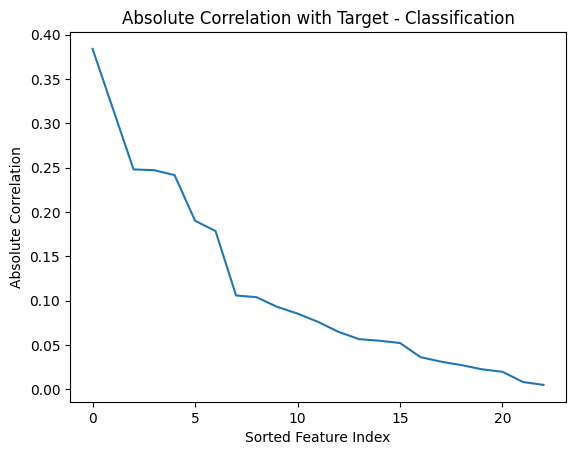

In [25]:
import matplotlib.pyplot as plt
# Classification

# Combine X and y for correlation
train_cls = X_train_cls_fe.copy()
train_cls['target'] = y_train_cls_processed.values

# Calculate correlation with target
corr_with_target = train_cls.corr()['target'].abs().sort_values(ascending=False)

# Remove the target itself from plotting
corr_features = corr_with_target.drop('target')

# Sort descending (already sorted, but safe)
corr_features = corr_features.sort_values(ascending=False)

plt.figure()
plt.plot(corr_features.values)
plt.title("Absolute Correlation with Target - Classification")
plt.xlabel("Sorted Feature Index")
plt.ylabel("Absolute Correlation")
plt.show()

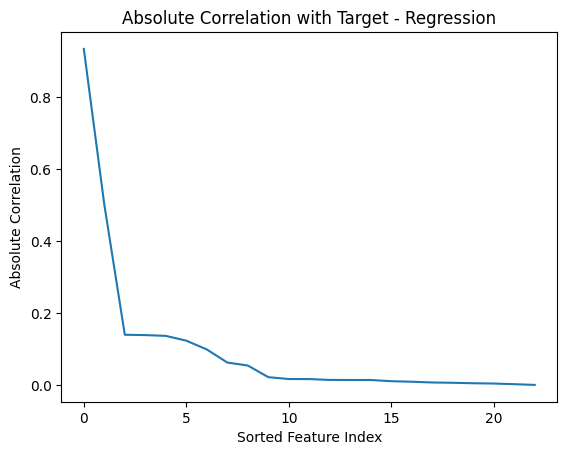

In [26]:
# Regression

# Combine X and y for correlation
train_reg = X_train_reg_fe.copy()
train_reg['target'] = y_train_reg_processed.values

# Calculate correlation with target
corr_with_target = train_reg.corr()['target'].abs().sort_values(ascending=False)

# Remove the target itself from plotting
corr_features = corr_with_target.drop('target')

# Sort descending (already sorted, but safe)
corr_features = corr_features.sort_values(ascending=False)

plt.figure()
plt.plot(corr_features.values)
plt.title("Absolute Correlation with Target - Regression")
plt.xlabel("Sorted Feature Index")
plt.ylabel("Absolute Correlation")
plt.show()

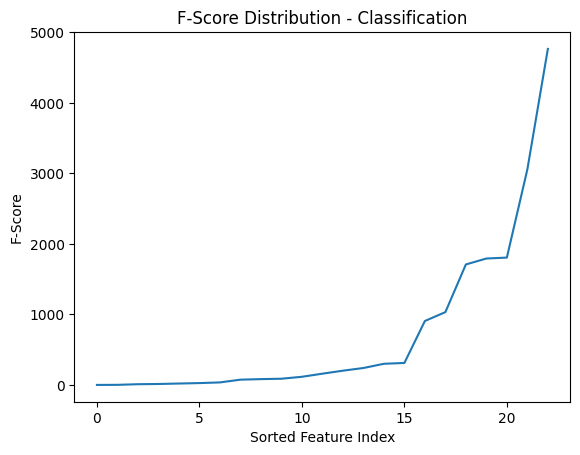

In [27]:
from sklearn.feature_selection import f_classif, f_regression
import matplotlib.pyplot as plt

# Classification
f_scores_cls, p_values_cls = f_classif(X_train_cls_fe, y_train_cls_processed.values.ravel())
# Sort scores with feature names
cls_sorted_idx = np.argsort(f_scores_cls)
cls_sorted_scores = f_scores_cls[cls_sorted_idx]

plt.figure()
plt.plot(cls_sorted_scores)
plt.title("F-Score Distribution - Classification")
plt.xlabel("Sorted Feature Index")
plt.ylabel("F-Score")
plt.show()


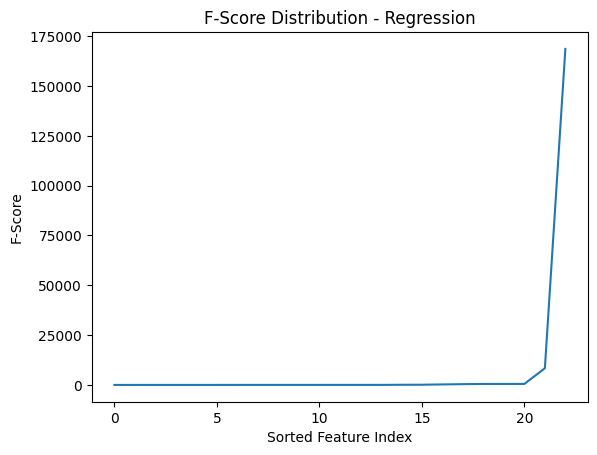

In [28]:
# Regression
f_scores_reg, p_values_reg = f_regression(X_train_reg_fe, y_train_reg_processed.values.ravel())
reg_sorted_idx = np.argsort(f_scores_reg)
reg_sorted_scores = f_scores_reg[reg_sorted_idx]

plt.figure()
plt.plot(reg_sorted_scores)
plt.title("F-Score Distribution - Regression")
plt.xlabel("Sorted Feature Index")
plt.ylabel("F-Score")
plt.show()

In [29]:
# Classification top and bottom features
cls_filter = pd.DataFrame({
    'feature': X_train_cls_fe.columns,
    'f_score': f_scores_cls,
    'p_value': p_values_cls
}).sort_values('f_score', ascending=False)

print("Classification Top 10:")
print(cls_filter.head(10))
print("\nClassification Bottom 5:")
print(cls_filter.tail(5))

Classification Top 10:
                           feature      f_score        p_value
5              loan_percent_income  4764.397402   0.000000e+00
4                    loan_int_rate  3056.684265   0.000000e+00
19      loan_grade_x_loan_int_rate  1805.955516   0.000000e+00
1                    person_income  1792.776871   0.000000e+00
9       person_home_ownership_RENT  1708.774032   0.000000e+00
7   person_home_ownership_MORTGAGE  1032.918437  1.606651e-222
6        cb_person_default_on_file   906.932350  4.582956e-196
3                        loan_amnt   312.112356   1.828922e-69
8        person_home_ownership_OWN   300.376571   6.176961e-67
2                person_emp_length   240.461196   5.276884e-54

Classification Bottom 5:
                           feature    f_score   p_value
0                       person_age  20.445150  0.000006
21  person_age_x_person_emp_length  13.937732  0.000189
14            loan_intent_PERSONAL  10.696597  0.001075
16            income_to_loan_ratio

In [30]:
# Regression top and bottom features
reg_filter = pd.DataFrame({
    'feature': X_train_reg_fe.columns,
    'f_score': f_scores_reg,
    'p_value': p_values_reg
}).sort_values('f_score', ascending=False)

print("Regression Top 10:")
print(reg_filter.head(10))
print("\Regression Bottom 5:")
print(reg_filter.tail(5))

Regression Top 10:
                             feature        f_score        p_value
3                         loan_grade  168593.078316   0.000000e+00
6          cb_person_default_on_file    8361.416492   0.000000e+00
4                          loan_amnt     498.293510  2.631872e-109
9         person_home_ownership_RENT     491.963796  5.897945e-108
7     person_home_ownership_MORTGAGE     476.244082  1.336866e-104
5                loan_percent_income     386.780623   1.847851e-85
19            loan_grade_x_loan_amnt     248.047051   1.283603e-55
20  loan_grade_x_loan_percent_income      99.042644   2.731236e-23
2                  person_emp_length      74.751724   5.653195e-18
21    person_age_x_person_emp_length      12.425983   4.241603e-04
\Regression Bottom 5:
                          feature   f_score   p_value
15            loan_intent_VENTURE  1.121677  0.289568
11          loan_intent_EDUCATION  0.730890  0.392603
14           loan_intent_PERSONAL  0.525050  0.468702
10  lo

###  Step 12: Feature Selection: Wrapper Method (RFE)

What is RFE?
1) Recursive Feature Elimination
2) Trains model repeatedly
3) Removes weakest feature each time
4) Finds optimal feature subset

In [31]:
from sklearn.feature_selection import RFE
from sklearn.ensemble import RandomForestClassifier

# Classification — select top 15 features
rfe_cls = RFE(
    estimator=RandomForestClassifier(n_estimators=50, random_state=42),
    n_features_to_select=15
)
rfe_cls.fit(X_train_cls_fe, y_train_cls_processed.values.ravel())

# Get selected features
selected_cls = X_train_cls_fe.columns[rfe_cls.support_].tolist()
removed_cls = X_train_cls_fe.columns[~rfe_cls.support_].tolist()

print(f"Selected features (cls): {selected_cls}")
print(f"Removed features (cls):  {removed_cls}")

Selected features (cls): ['person_age', 'person_income', 'person_emp_length', 'loan_amnt', 'loan_int_rate', 'loan_percent_income', 'person_home_ownership_MORTGAGE', 'person_home_ownership_RENT', 'income_to_loan_ratio', 'loan_to_age_ratio', 'income_per_emp_year', 'loan_grade_x_loan_int_rate', 'loan_grade_x_loan_percent_income', 'person_age_x_person_emp_length', 'debt_burden_score']
Removed features (cls):  ['cb_person_default_on_file', 'person_home_ownership_OWN', 'loan_intent_DEBTCONSOLIDATION', 'loan_intent_EDUCATION', 'loan_intent_HOMEIMPROVEMENT', 'loan_intent_MEDICAL', 'loan_intent_PERSONAL', 'loan_intent_VENTURE']


In [32]:
from sklearn.feature_selection import RFE
from sklearn.ensemble import RandomForestRegressor

# Regression — select top 15 features
rfe_reg = RFE(
    estimator=RandomForestRegressor(n_estimators=50, random_state=42),
    n_features_to_select=15
)
rfe_reg.fit(X_train_reg_fe, y_train_reg_processed.values.ravel())

# Get selected features
selected_reg = X_train_reg_fe.columns[rfe_reg.support_].tolist()
removed_reg = X_train_reg_fe.columns[~rfe_reg.support_].tolist()

print(f"Selected features (cls): {selected_reg}")
print(f"Removed features (cls):  {removed_reg}")

Selected features (cls): ['person_age', 'person_income', 'person_emp_length', 'loan_grade', 'loan_amnt', 'loan_percent_income', 'person_home_ownership_MORTGAGE', 'loan_intent_EDUCATION', 'income_to_loan_ratio', 'loan_to_age_ratio', 'income_per_emp_year', 'loan_grade_x_loan_amnt', 'loan_grade_x_loan_percent_income', 'person_age_x_person_emp_length', 'debt_burden_score']
Removed features (cls):  ['cb_person_default_on_file', 'person_home_ownership_OWN', 'person_home_ownership_RENT', 'loan_intent_DEBTCONSOLIDATION', 'loan_intent_HOMEIMPROVEMENT', 'loan_intent_MEDICAL', 'loan_intent_PERSONAL', 'loan_intent_VENTURE']


### Step 13: Feature Selection: Embedded Method

What is Embedded Method?
1) Feature importance from trained model
2) Most common — Random Forest feature importance
3) Drops features below importance threshold

In [33]:
from sklearn.ensemble import RandomForestClassifier

# Classification
rf_cls = RandomForestClassifier(n_estimators=100, random_state=42)
rf_cls.fit(X_train_cls_fe, y_train_cls_processed.values.ravel())

# Get feature importances
importance_cls = pd.DataFrame({
    'feature': X_train_cls_fe.columns,
    'importance': rf_cls.feature_importances_
}).sort_values('importance', ascending=False)

print("Classification Feature Importance:")
print(importance_cls)

# Drop features below threshold (importance < 0.01)
embedded_drop_cls = importance_cls[
    importance_cls['importance'] < 0.01]['feature'].tolist()
print(f"\nFeatures to drop: {embedded_drop_cls}")

Classification Feature Importance:
                             feature  importance
5                loan_percent_income    0.173088
1                      person_income    0.089163
19        loan_grade_x_loan_int_rate    0.089088
4                      loan_int_rate    0.086044
20  loan_grade_x_loan_percent_income    0.079609
22                 debt_burden_score    0.060058
9         person_home_ownership_RENT    0.053993
16              income_to_loan_ratio    0.046840
18               income_per_emp_year    0.046072
3                          loan_amnt    0.043006
17                 loan_to_age_ratio    0.033335
2                  person_emp_length    0.029736
21    person_age_x_person_emp_length    0.027989
7     person_home_ownership_MORTGAGE    0.026761
0                         person_age    0.022779
10     loan_intent_DEBTCONSOLIDATION    0.017852
8          person_home_ownership_OWN    0.017496
13               loan_intent_MEDICAL    0.015354
12       loan_intent_HOMEIMPROVEME

In [34]:
from sklearn.ensemble import RandomForestRegressor

# Regression
rf_reg = RandomForestRegressor(n_estimators=100, random_state=42)
rf_reg.fit(X_train_reg_fe, y_train_reg_processed.values.ravel())

# Get feature importances
importance_reg = pd.DataFrame({
    'feature': X_train_reg_fe.columns,
    'importance': rf_reg.feature_importances_
}).sort_values('importance', ascending=False)

print("Regression Feature Importance:")
print(importance_reg)

# Drop features below threshold (importance < 0.01)
embedded_drop_reg = importance_reg[
    importance_reg['importance'] < 0.01]['feature'].tolist()
print(f"\nFeatures to drop: {embedded_drop_reg}")

Regression Feature Importance:
                             feature  importance
3                         loan_grade    0.902593
17                 loan_to_age_ratio    0.011354
18               income_per_emp_year    0.011292
22                 debt_burden_score    0.010375
16              income_to_loan_ratio    0.010209
21    person_age_x_person_emp_length    0.008467
1                      person_income    0.006826
5                loan_percent_income    0.006277
20  loan_grade_x_loan_percent_income    0.006099
0                         person_age    0.004617
2                  person_emp_length    0.003686
4                          loan_amnt    0.003615
19            loan_grade_x_loan_amnt    0.003449
14              loan_intent_PERSONAL    0.001370
11             loan_intent_EDUCATION    0.001342
15               loan_intent_VENTURE    0.001315
13               loan_intent_MEDICAL    0.001308
10     loan_intent_DEBTCONSOLIDATION    0.001299
7     person_home_ownership_MORTGAGE  

### Combine Result Analysis

In [35]:
# Regression — drop loan_intent columns
# All 3 methods agree they are weak for predicting interest rate
# EDA confirmed no clear pattern


# Classification — drop nothing
final_drop_cls = []
X_train_cls_fe.drop(columns=final_drop_cls, inplace=True)
X_val_cls_fe.drop(columns=final_drop_cls, inplace=True)
X_test_cls_fe.drop(columns=final_drop_cls, inplace=True)


# Regression
final_drop_reg = [
    'cb_person_default_on_file',
    'loan_intent_DEBTCONSOLIDATION',
    'loan_intent_EDUCATION',
    'loan_intent_HOMEIMPROVEMENT',
    'loan_intent_MEDICAL',
    'loan_intent_PERSONAL',
    'loan_intent_VENTURE'
]
X_train_reg_fe.drop(columns=final_drop_reg, inplace=True)
X_val_reg_fe.drop(columns=final_drop_reg, inplace=True)
X_test_reg_fe.drop(columns=final_drop_reg, inplace=True)

In [36]:
print("final shape cls: ",X_train_cls_fe.shape)
print("final shape reg: ",X_train_reg_fe.shape)

final shape cls:  (27577, 23)
final shape reg:  (24943, 16)


In [37]:
# Save for reference
print("Classification final features:")
print(X_train_cls_fe.columns.tolist())

print("\nRegression final features:")
print(X_train_reg_fe.columns.tolist())

Classification final features:
['person_age', 'person_income', 'person_emp_length', 'loan_amnt', 'loan_int_rate', 'loan_percent_income', 'cb_person_default_on_file', 'person_home_ownership_MORTGAGE', 'person_home_ownership_OWN', 'person_home_ownership_RENT', 'loan_intent_DEBTCONSOLIDATION', 'loan_intent_EDUCATION', 'loan_intent_HOMEIMPROVEMENT', 'loan_intent_MEDICAL', 'loan_intent_PERSONAL', 'loan_intent_VENTURE', 'income_to_loan_ratio', 'loan_to_age_ratio', 'income_per_emp_year', 'loan_grade_x_loan_int_rate', 'loan_grade_x_loan_percent_income', 'person_age_x_person_emp_length', 'debt_burden_score']

Regression final features:
['person_age', 'person_income', 'person_emp_length', 'loan_grade', 'loan_amnt', 'loan_percent_income', 'person_home_ownership_MORTGAGE', 'person_home_ownership_OWN', 'person_home_ownership_RENT', 'income_to_loan_ratio', 'loan_to_age_ratio', 'income_per_emp_year', 'loan_grade_x_loan_amnt', 'loan_grade_x_loan_percent_income', 'person_age_x_person_emp_length', 'debt

### Step 14: Feature Importance Check

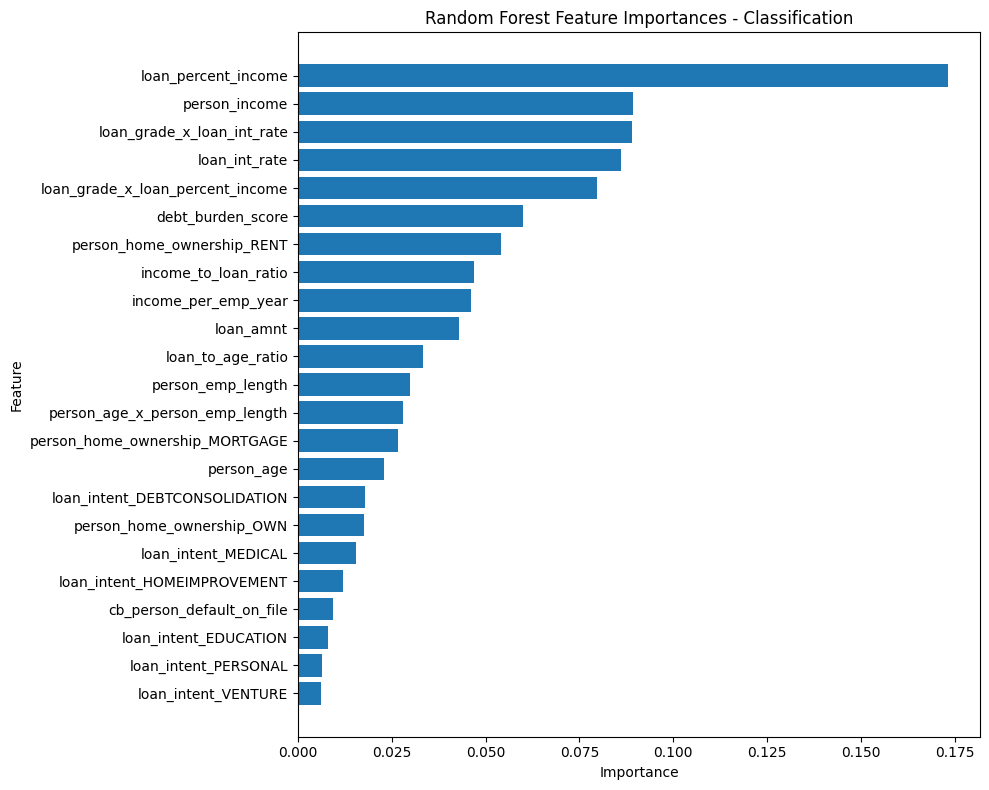

In [38]:
import seaborn as sns

rf_cls_final = RandomForestClassifier(n_estimators=100, random_state=42)
rf_cls_final.fit(X_train_cls_fe, y_train_cls_processed.values.ravel())

importance_cls_final = pd.DataFrame({
    'feature': X_train_cls_fe.columns,
    'importance': rf_cls_final.feature_importances_
}).sort_values('importance', ascending=True)

# Plot horizontal bar chart
plt.figure(figsize=(10, 8))
plt.barh(
    importance_cls_final["feature"],
    importance_cls_final["importance"]
)

plt.title("Random Forest Feature Importances - Classification")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

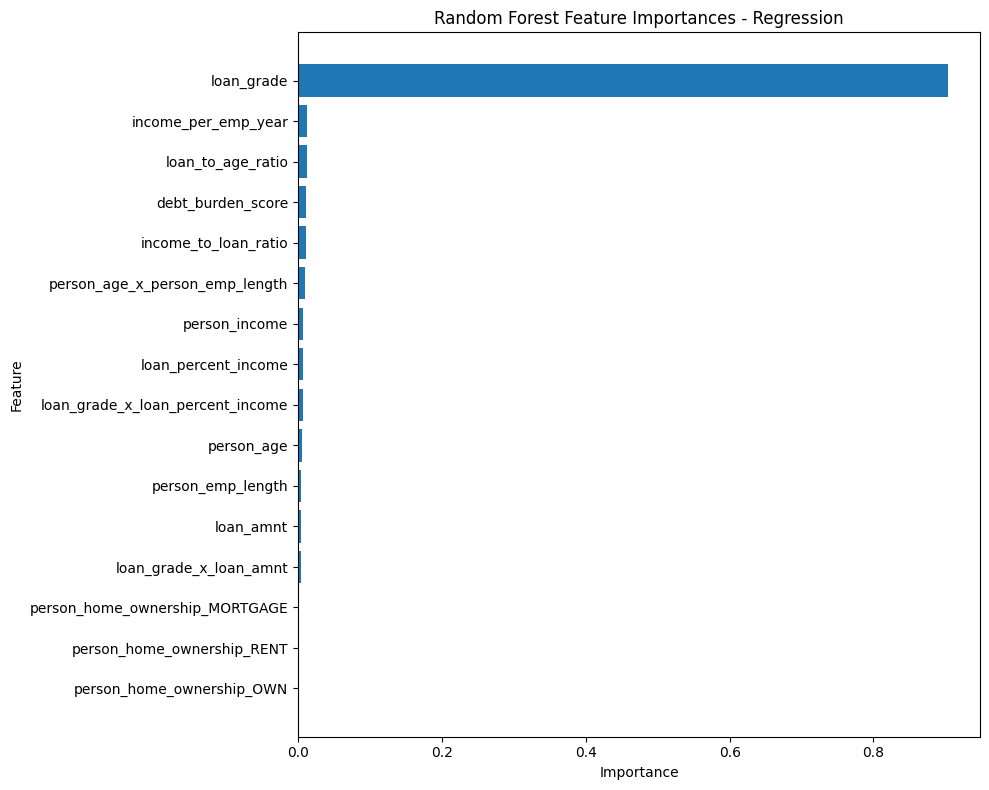

In [39]:
import seaborn as sns

rf_reg_final = RandomForestRegressor(n_estimators=100, random_state=42)
rf_reg_final.fit(X_train_reg_fe, y_train_reg_processed.values.ravel())

importance_reg_final = pd.DataFrame({
    'feature': X_train_reg_fe.columns,
    'importance': rf_reg_final.feature_importances_
}).sort_values('importance', ascending=True)

# Plot horizontal bar chart
plt.figure(figsize=(10, 8))
plt.barh(
    importance_reg_final["feature"],
    importance_reg_final["importance"]
)

plt.title("Random Forest Feature Importances - Regression")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

###  Step 15: Compare Before vs After Feature Engineering

In [40]:
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import accuracy_score, f1_score, r2_score, mean_squared_error

# Load original preprocessed data (before FE)
# Compare with current FE data

# Classification — Before FE
rf_before_cls = RandomForestClassifier(n_estimators=100, random_state=42)
rf_before_cls.fit(X_train_cls_processed, y_train_cls_processed.values.ravel())
y_pred_before_cls = rf_before_cls.predict(X_val_cls_processed)

# Classification — After FE
rf_after_cls = RandomForestClassifier(n_estimators=100, random_state=42)
rf_after_cls.fit(X_train_cls_fe, y_train_cls_processed.values.ravel())
y_pred_after_cls = rf_after_cls.predict(X_val_cls_fe)

# Print comparison
print("=== Classification ===")
print(f"Before FE — Accuracy: {accuracy_score(y_val_cls_processed, y_pred_before_cls):.4f}")
print(f"After FE  — Accuracy: {accuracy_score(y_val_cls_processed, y_pred_after_cls):.4f}")
print(f"Before FE — F1: {f1_score(y_val_cls_processed, y_pred_before_cls):.4f}")
print(f"After FE  — F1: {f1_score(y_val_cls_processed, y_pred_after_cls):.4f}")


=== Classification ===
Before FE — Accuracy: 0.9288
After FE  — Accuracy: 0.9296
Before FE — F1: 0.8100
After FE  — F1: 0.8114


In [41]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import accuracy_score, f1_score, r2_score, mean_squared_error

# Load original preprocessed data (before FE)
# Compare with current FE data

# Classification — Before FE
rf_before_reg = RandomForestRegressor(n_estimators=100, random_state=42)
rf_before_reg.fit(X_train_reg_processed, y_train_reg_processed.values.ravel())
y_pred_before_reg = rf_before_reg.predict(X_val_reg_processed)

# Classification — After FE
rf_after_reg = RandomForestRegressor(n_estimators=100, random_state=42)
rf_after_reg.fit(X_train_reg_fe, y_train_reg_processed.values.ravel())
y_pred_after_reg = rf_after_reg.predict(X_val_reg_fe)

# Print comparison
print("=== Regression ===")
print(f"Before FE — r2_score: {r2_score(y_val_reg_processed, y_pred_before_reg):.4f}")
print(f"After FE  — r2_score: {r2_score(y_val_reg_processed, y_pred_after_reg):.4f}")
print(f"Before FE — mean_squared_error: {mean_squared_error(y_val_reg_processed, y_pred_before_reg):.4f}")
print(f"After FE  — mean_squared_error: {mean_squared_error(y_val_reg_processed, y_pred_after_reg):.4f}")


=== Regression ===
Before FE — r2_score: 0.9127
After FE  — r2_score: 0.9154
Before FE — mean_squared_error: 0.9797
After FE  — mean_squared_error: 0.9488


### Step 16: Verify Final Features

In [42]:
print("FEATURE ENGINEERING VERIFICATION")
print()

for name, X in [
    ('X_train_cls', X_train_cls_fe),
    ('X_val_cls',   X_val_cls_fe),
    ('X_test_cls',  X_test_cls_fe),
    ('X_train_reg', X_train_reg_fe),
    ('X_val_reg',   X_val_reg_fe),
    ('X_test_reg',  X_test_reg_fe)]:
    
    print(f"\n{name}:")
    print(f"  Shape:         {X.shape}")
    print(f"  Missing:       {X.isnull().sum().sum()}")
    print(f"  Infinite:      {np.isinf(X).sum().sum()}")
    print(f"  Categorical:   {X.select_dtypes(include='object').shape[1]}")
    print(f"  Constant cols: {(X.nunique() == 1).sum()}")

FEATURE ENGINEERING VERIFICATION


X_train_cls:
  Shape:         (27577, 23)
  Missing:       0
  Infinite:      0
  Categorical:   0
  Constant cols: 0

X_val_cls:
  Shape:         (2444, 23)
  Missing:       0
  Infinite:      0
  Categorical:   0
  Constant cols: 0

X_test_cls:
  Shape:         (2444, 23)
  Missing:       0
  Infinite:      0
  Categorical:   0
  Constant cols: 0

X_train_reg:
  Shape:         (24943, 16)
  Missing:       0
  Infinite:      0
  Categorical:   0
  Constant cols: 0

X_val_reg:
  Shape:         (2210, 16)
  Missing:       0
  Infinite:      0
  Categorical:   0
  Constant cols: 0

X_test_reg:
  Shape:         (2210, 16)
  Missing:       0
  Infinite:      0
  Categorical:   0
  Constant cols: 0


### Step 17: Save Engineered Splits

In [43]:
# Load config
with open(config_file, "r") as f:
    config = yaml.safe_load(f)

    root_dir = os.path.dirname(os.path.dirname(os.path.abspath(config_file)))
    engineered_path = os.path.join(root_dir, config['paths']['engineered_data'])

# Create folder if it doesn't exist
os.makedirs(engineered_path, exist_ok=True)

In [44]:
# Helper function to save splits
def save_engineered(X, y, prefix, task_type):
    X.to_csv(os.path.join(engineered_path, f"X_{prefix}_{task_type}.csv"), index=False)
    y.to_csv(os.path.join(engineered_path, f"y_{prefix}_{task_type}.csv"), index=False)


In [45]:
# Save Classification engineered
save_engineered(X_train_cls_fe, y_train_cls_processed, "train", "cls_engineered")
save_engineered(X_val_cls_fe,   y_val_cls_processed,   "val",   "cls_engineered")
save_engineered(X_test_cls_fe,  y_test_cls_processed,  "test",  "cls_engineered")

In [46]:
# Save Regression engineered
save_engineered(X_train_reg_fe, y_train_reg_processed, "train", "reg_engineered")
save_engineered(X_val_reg_fe,   y_val_reg_processed,   "val",   "reg_engineered")
save_engineered(X_test_reg_fe,  y_test_reg_processed,  "test",  "reg_engineered")

### Step 18: Save Feature Engineering Pipeline

In [47]:
import joblib

# Save all FE transformers and feature lists
fe_pipeline = {
    # Scalers for new features
    'scaler_cls_fe': scaling_cls_fe,
    'scaler_reg_fe': scaling_reg_fe,
    
    # Final feature lists
    'final_features_cls': X_train_cls_fe.columns.tolist(),
    'final_features_reg': X_train_reg_fe.columns.tolist(),
    
    # Drop lists for reference
    'final_drop_cls': final_drop_cls,
    'final_drop_reg': final_drop_reg,
    
    # Variance threshold
    'variance_threshold_cls': vt_cls,
    'variance_threshold_reg': vt_reg,
}

# Save to models/
joblib.dump(fe_pipeline, '../models/fe_pipeline.joblib')
print("✅ FE pipeline saved successfully")

✅ FE pipeline saved successfully


### Step 19: Save Feature List

In [48]:
import json

# Save final feature lists as JSON
# Useful for API — know exactly what features to expect

feature_lists = {
    'classification': {
        'features': X_train_cls_fe.columns.tolist(),
        'n_features': len(X_train_cls_fe.columns),
        'target': 'loan_status'
    },
    'regression': {
        'features': X_train_reg_fe.columns.tolist(),
        'n_features': len(X_train_reg_fe.columns),
        'target': 'loan_int_rate'
    }
}

# Save to models/
with open('../models/feature_lists.json', 'w') as f:
    json.dump(feature_lists, f, indent=4)

print("✅ Feature lists saved")
print(f"Classification features: {len(X_train_cls_fe.columns)}")
print(f"Regression features: {len(X_train_reg_fe.columns)}")

✅ Feature lists saved
Classification features: 23
Regression features: 16


### Step 20: Document Report

In [49]:
# see the file in docs/feature_engineering_report.md